# **Project: Diabetes Prediction using Machine Learning**

### **Objective**: To build a predictive model that determines whether a patient has diabetes based on diagnostic measurements.

### **Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### **Reading the Dataset**

In [2]:
df = pd.read_csv ('/content/drive/MyDrive/Datasets/diabetes.csv')
df.head ()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### **Exploratory Data Analysis**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


768 rows and 9 columns and it looks like the datatype is all set perfectly

In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


No null values

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicated data, which implies fairly clean data

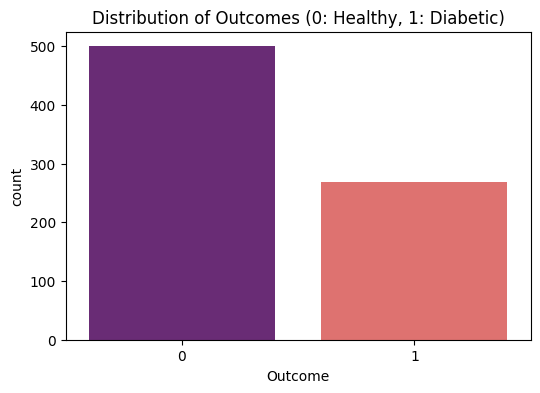

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='magma')
plt.title('Distribution of Outcomes (0: Healthy, 1: Diabetic)')
plt.show()


print(df['Outcome'].value_counts(normalize=True) * 100)

Though the target column is imbalanced, but its very moderate.

In [8]:
df.describe ()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


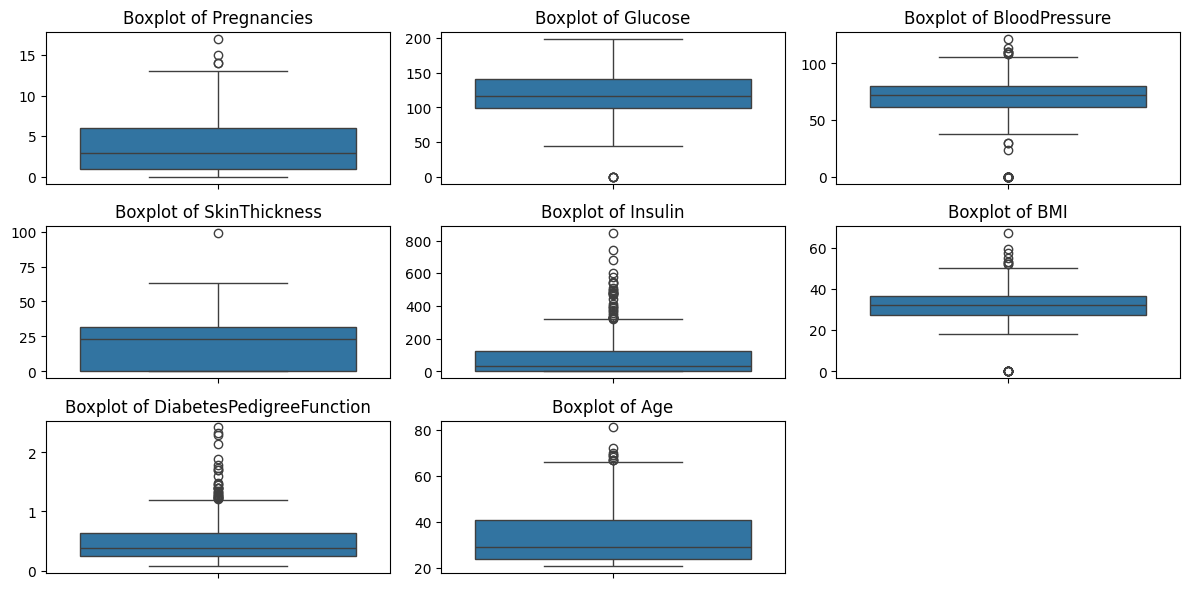

In [11]:
columns_to_plot = df.drop(columns='Outcome').columns

plt.figure(figsize=(12,6))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

Interpretations:

1. Pregnancies is right skewed. Normal behaviour. All good.

2. Glucose wide spread, 0 value present which is invalid.

3. Some extreme low values including 0, and few outliers. BP = 0 is impossible, thus is invalid.

4. Skin Thickness has some large outliers and 0 is present which is invalid, indicating possible missing data.

5. Insulin is right skewed and many outliers. Again 0 is invalid, indicating null values.

6. BMI has some outliers and also invald 0 values.

7. Diabetes Pedigree Functon is heavily right skewed. Many outliers. It is genetically influenced so varies widely. Needs scaling.

8. Age is normally distributed.

Need to Replace 0 with null ie np.nan and replace with median as it is most stable with having outliers

In [13]:
cols = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']

for col in cols:
  df[col] = df[col].replace(0 , np.nan)
  df[col].fillna (df[col].median() , inplace=True)

In [18]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Now data looks fairly ok.

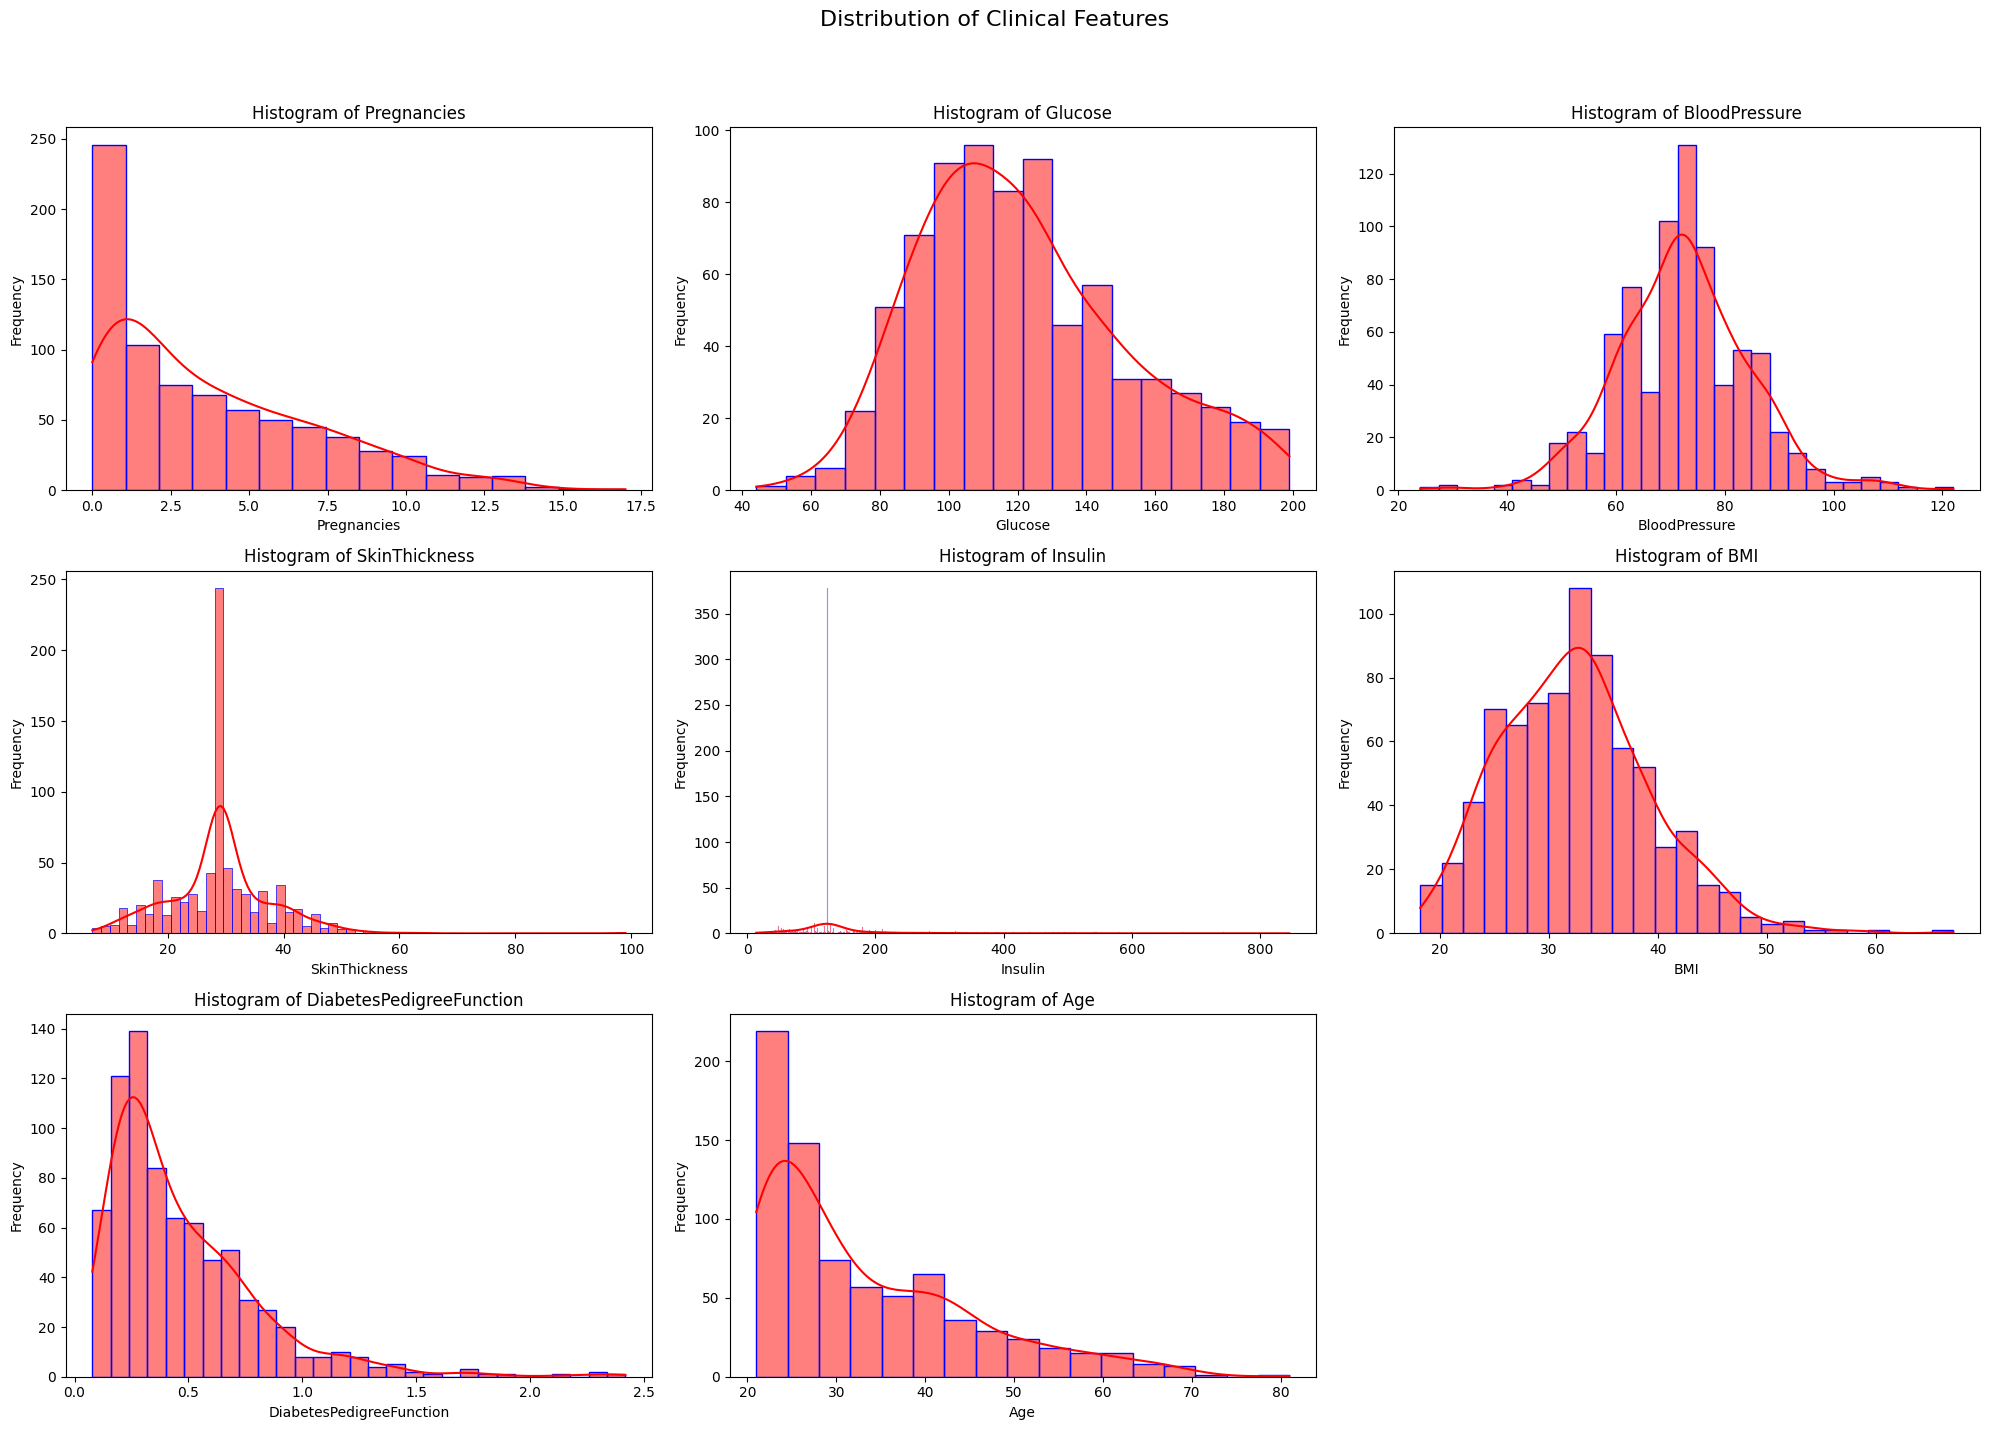

In [22]:
columns_to_plot = df.drop(columns='Outcome').columns

plt.figure(figsize=(20, 15))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column], kde=True, color='red', edgecolor='blue')
    plt.title(f'Histogram of {column}')
    plt.ylabel('Frequency')

plt.suptitle('Distribution of Clinical Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Most data seems left skewed.

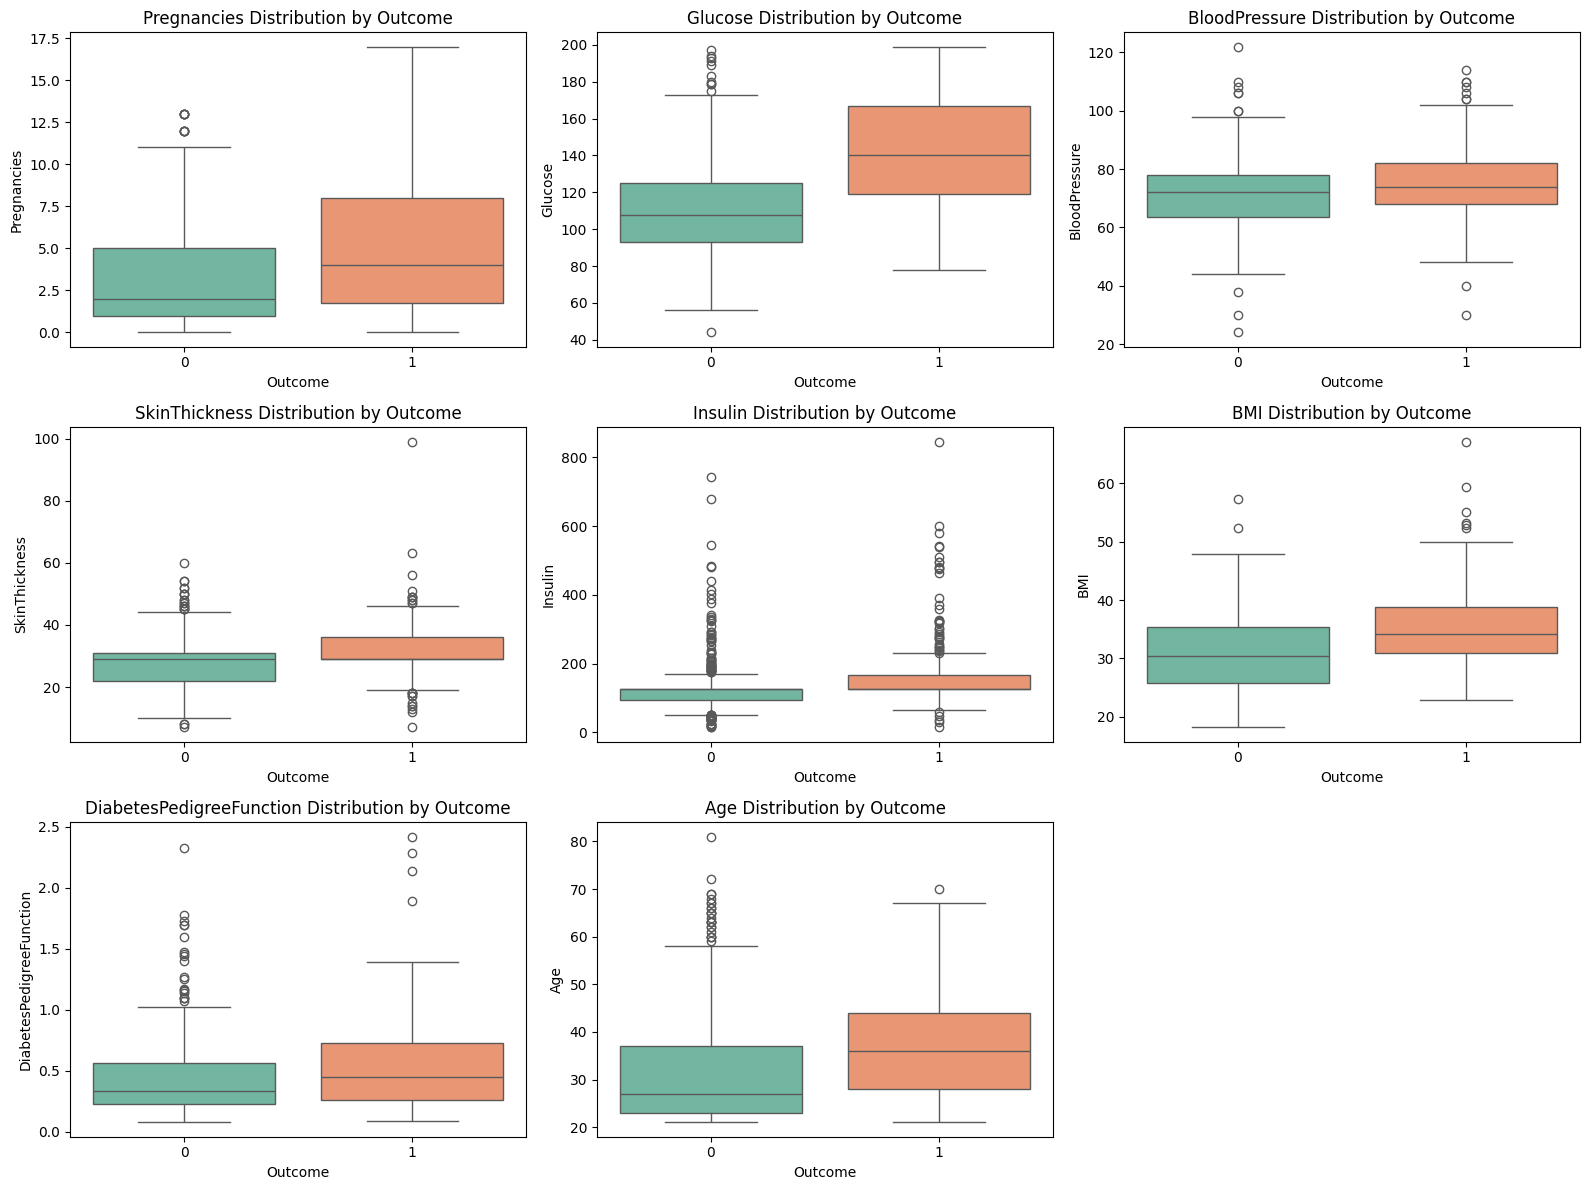

In [23]:
plt.figure(figsize=(16, 12))
features = df.columns[:-1]

for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
    plt.title(f'{col} Distribution by Outcome')

plt.tight_layout()
plt.show()

Interpretation:

1. Glucose: Diabetic group median significantly higher, means clear separation between classes.

2. BMI: Diabetic group has higher median BMI, means, higher BMI strongly correlates with diabetes risk.

3. Age: Diabetic is generally older group.

4. Pregnanies: Diabetic group shows higher values, implying more pregnancies higher likelyhood of diabetes.

5. Insulin: Slightly higher but heavy overlap, implying weak predictor.

6. Skin Thickness: Mild Correlation.

7. BP: Almost overlapping, weak predictor.

8. Diabetes Pedigree Function: Large Overlap, slightly higher for diabetic. So genetic factor matters but not strongly separable alone.

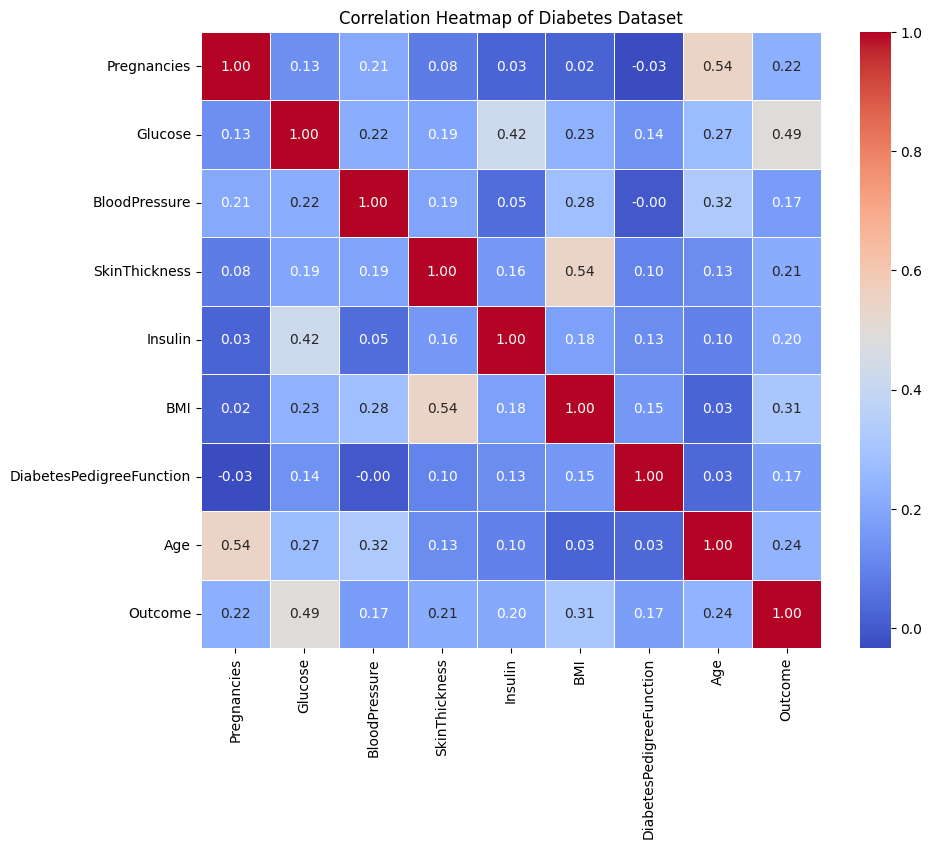

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

This confrms that Glucose, BMI and Age are strong separators.

Best feature is Glucose but its not that high with 0.49.

No feature is correlated with each other that means no multicollinearity which is good.

No single feature dominates completely.

Need of feature engineering.

### **But first we need to handle skewness.**

In [30]:
df1 = df.copy()

In [31]:
df1['Insulin'] = np.log1p (df['Insulin'])

In [32]:
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,4.836282,33.6,0.627,50,1
1,1,85.0,66.0,29.0,4.836282,26.6,0.351,31,0
2,8,183.0,64.0,29.0,4.836282,23.3,0.672,32,1
3,1,89.0,66.0,23.0,4.553877,28.1,0.167,21,0
4,0,137.0,40.0,35.0,5.129899,43.1,2.288,33,1


### **Feature Engineering**

In [33]:
# Interaction features
df1['BMI_Age'] = df1['BMI'] * df1['Age']
df1['Glucose_BMI'] = df1['Glucose'] * df1['BMI']
df1['Preg_Age'] = df1['Pregnancies'] * df1['Age']

# Domain features
df1['High_Glucose'] = (df1['Glucose'] > 140).astype(int)
df1['Is_Obese'] = (df1['BMI'] >= 30).astype(int)

In [34]:
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI,Preg_Age,High_Glucose,Is_Obese
0,6,148.0,72.0,35.0,4.836282,33.6,0.627,50,1,1680.0,4972.8,300,1,1
1,1,85.0,66.0,29.0,4.836282,26.6,0.351,31,0,824.6,2261.0,31,0,0
2,8,183.0,64.0,29.0,4.836282,23.3,0.672,32,1,745.6,4263.9,256,1,0
3,1,89.0,66.0,23.0,4.553877,28.1,0.167,21,0,590.1,2500.9,21,0,0
4,0,137.0,40.0,35.0,5.129899,43.1,2.288,33,1,1422.3,5904.7,0,0,1


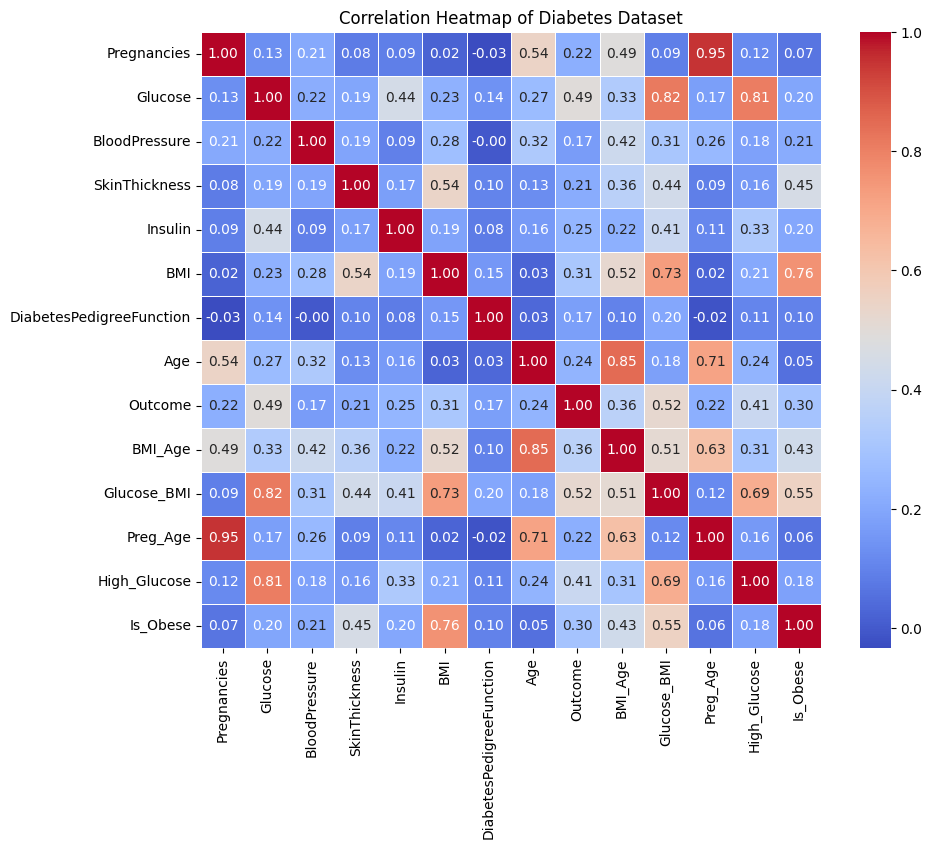

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

Cleaner Version

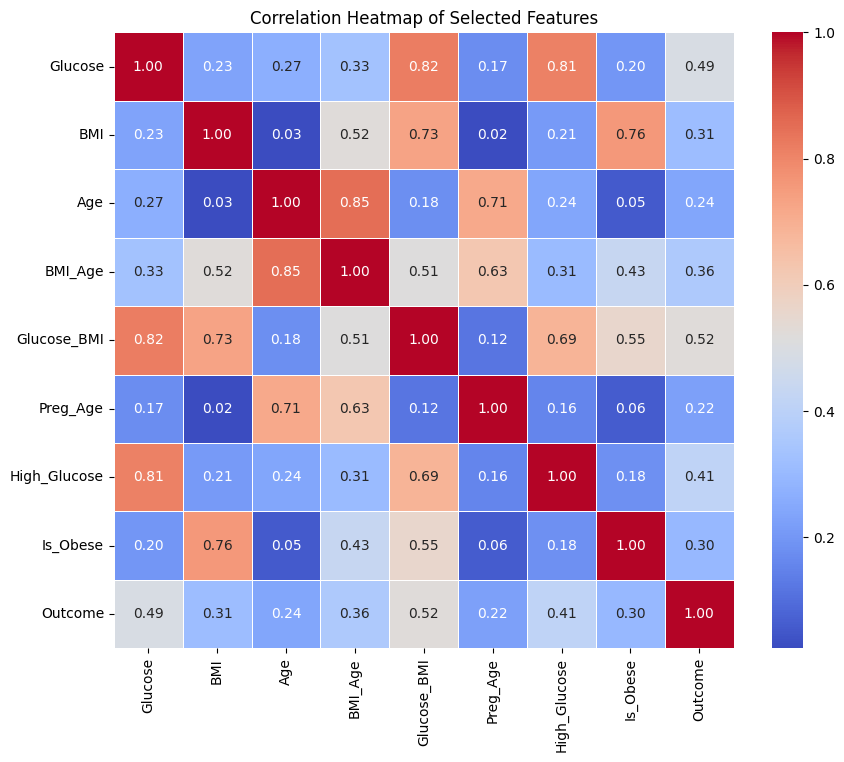

In [38]:
plt.figure(figsize=(10, 8))

cols = ['Glucose', 'BMI', 'Age', 'BMI_Age', 'Glucose_BMI', 'Preg_Age', 'High_Glucose', 'Is_Obese', 'Outcome']

sns.heatmap(df1[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Selected Features')
plt.show()

Now we see some better features to use for the model.

### **Dropping Redudndant Reatures**

Since Glucose_BMI shows higher correlation with the target compared to Glucose and both are highly correlated, Glucose was dropped to avoid redundancy while retaining the stronger feature.

Preg_Age and Pregnancy has high correlation of 0.95 and almost identical implying multicollinearity and duplicate signal.

Is_Obese is poorer signal than BMI and they have high correlaton of 0.76, so we drop it.

In [40]:
features_to_drop = ['Glucose', 'Preg_Age' , 'Is_Obese']

df2 = df1.drop (features_to_drop , axis=1)

df2.head()

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI,High_Glucose
0,6,72.0,35.0,4.836282,33.6,0.627,50,1,1680.0,4972.8,1
1,1,66.0,29.0,4.836282,26.6,0.351,31,0,824.6,2261.0,0
2,8,64.0,29.0,4.836282,23.3,0.672,32,1,745.6,4263.9,1
3,1,66.0,23.0,4.553877,28.1,0.167,21,0,590.1,2500.9,0
4,0,40.0,35.0,5.129899,43.1,2.288,33,1,1422.3,5904.7,0


Feature selection was performed after feature engineering to reduce redundancy while preserving the most informative representations of the data.

## **Modelling**

### **Splitting the data between features and target**

In [41]:
X = df2.drop('Outcome', axis=1)
y = df2['Outcome']

### **Train Test Split**

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Importing Libraries**

In [50]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### **Model Dictionary with Scaling where needed**

In [48]:
models = {
    'logistic': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    'svm': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ]),

    'rf': RandomForestClassifier(),

    'dt': DecisionTreeClassifier(),

    'xgb': XGBClassifier(eval_metric='logloss')
}

### **Param Grids**

In [49]:
param_grids = {

    'logistic': {
        'model__C': [0.01, 0.1, 1, 10]
    },

    'svm': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },

    'rf': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10]
    },

    'dt': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10]
    },

    'xgb': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

### **Cross valdation and Tuning Loop**

In [61]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

results = []
best_models = {}

for name, model in models.items():
    print(f"\nRunning {name}...")

    search = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=10,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    # Predictions
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Metrics
    test_auc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Print
    print("Best Params:", search.best_params_)
    print("ROC-AUC:", test_auc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Store
    results.append({
        'model': name,
        'best_params': search.best_params_,
        'cv_auc': search.best_score_,
        'test_auc': test_auc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })


Running logistic...
Best Params: {'model__C': 1}
ROC-AUC: 0.8155555555555556
Precision: 0.5869565217391305
Recall: 0.5
F1 Score: 0.54
Confusion Matrix:
 [[81 19]
 [27 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


Running svm...
Best Params: {'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.1}
ROC-AUC: 0.8053703703703704
Precision: 0.65
Recall: 0.48148148148148145
F1 Score: 0.5531914893617021
Confusion Matrix:
 [[86 14]
 [28 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80       100
           1       0.65      0.48      0.55        54

    accuracy                           0.73       

### **Compare Results**

In [62]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='test_auc', ascending=False)

,model,best_params,cv_auc,test_auc,precision,recall,f1_score
0,logistic,{'model__C': 1},0.840226,0.815556,0.586957,0.500000,0.540000
1,svm,"{'model__kernel': 'linear', 'model__gamma': 's...",0.834232,0.805370,0.650000,0.481481,0.553191
4,xgb,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.825087,0.805185,0.577778,0.481481,0.525253
2,rf,"{'n_estimators': 300, 'min_samples_split': 10,...",0.835331,0.803333,0.622222,0.518519,0.565657
3,dt,"{'min_samples_split': 2, 'max_depth': 3}",0.788306,0.764907,0.648649,0.444444,0.527473


Best AUC = Logistic

But this is healthcare. Recall is best here.

Lookng at confusion Matrix FN of Logistic = 27 which is bad.

Least false negative is with random forest with 26. Which has highest recall.

# **Best Model = Random Forest**


In [71]:
best_model = best_models['rf']

### **Generating Predictions**

In [72]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

### **Creating Results**

In [73]:
results_df = X_test.copy()

results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred
results_df['Probability'] = y_pred_proba

In [75]:
results_df['Correct'] = (results_df['Actual'] == results_df['Predicted']).astype(int)

In [76]:
results_df

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI,High_Glucose,Actual,Predicted,Probability,Correct
44,7,64.0,29.0,4.836282,27.4,0.294,40,1096.0,4356.6,1,0,1,0.551388,0
672,10,106.0,23.0,3.912023,35.5,0.285,47,1668.5,2414.0,0,0,0,0.212925,1
700,2,76.0,27.0,5.303305,35.9,0.483,26,933.4,4379.8,0,0,0,0.253420,1
630,7,64.0,29.0,4.836282,27.4,0.732,34,931.6,3123.6,0,1,0,0.277590,0
81,2,72.0,29.0,4.836282,32.3,0.102,22,710.6,2390.2,0,0,0,0.051241,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,3,58.0,11.0,4.007333,24.8,0.267,22,545.6,2182.4,0,0,0,0.022033,1
637,2,76.0,18.0,4.204693,31.6,0.649,23,726.8,2970.4,0,0,0,0.059293,1
593,2,52.0,22.0,4.753590,28.5,1.699,25,712.5,2337.0,0,0,0,0.119713,1
425,4,78.0,39.0,5.627621,37.0,0.264,31,1147.0,6808.0,1,1,1,0.750650,1


In [77]:
false_negatives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]
false_positives = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]

In [78]:
print("False Negatives:", len(false_negatives))
print("False Positives:", len(false_positives))

False Negatives: 26
False Positives: 17


In [79]:
results_df['Risk_Level'] = results_df['Probability'].apply(
    lambda x: 'High' if x > 0.7 else ('Medium' if x > 0.4 else 'Low')
)

### **Exporting to CSV**

In [80]:
results_df.to_csv('diabetes_predictions.csv', index=False)

### **Save Model**

In [81]:
import joblib

joblib.dump(best_model, 'random_forest.pkl')

['random_forest.pkl']

📌 Conclusion

This project aimed to predict diabetes outcomes using clinical and demographic features through a structured machine learning pipeline, including data cleaning, feature engineering, model training, and evaluation.

---

🔍 Key Insights

- The dataset contained moderate class imbalance, which did not require aggressive resampling.
- Glucose remained the most influential feature, though engineered features improved overall predictive power.
- Several features had invalid zero values, which were treated as missing and imputed using median values.
- Insulin showed strong skewness, which was corrected using log transformation.
- Feature engineering introduced meaningful interactions such as:
  - "BMI_Age"
  - "Glucose_BMI"
- Redundant and highly correlated features ("Glucose", "Preg_Age", "Is_Obese") were removed to reduce multicollinearity.

---

⚙️ Model Comparison

Multiple models were trained and tuned using RandomizedSearchCV with 5-fold cross-validation:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- Decision Tree
- XGBoost

Evaluation metrics included:

- ROC-AUC
- Precision
- Recall
- F1-score

---

📊 Model Performance Summary

Model| ROC-AUC| Precision| Recall| F1 Score

Logistic Regression| 0.815| 0.59| 0.50| 0.54

SVM| 0.805| 0.65| 0.48| 0.55

XGBoost| 0.805| 0.58| 0.48| 0.53

Random Forest| 0.803| 0.62| 0.52| 0.57

Decision Tree| 0.764| 0.65| 0.44| 0.53

---

🏆 Final Model Selection

Although Logistic Regression achieved the highest ROC-AUC, it resulted in a higher number of false negatives (27).

In contrast, Random Forest produced fewer false negatives (26) and achieved the highest recall (≈0.52).

👉 In a healthcare setting, recall is more critical than AUC, as missing a diabetic patient can have serious consequences.

Therefore, Random Forest was selected as the final model.

---

📊 Final Performance (Random Forest)

- Accuracy: ~72–73%
- Precision: ~0.62
- Recall: ~0.52
- F1 Score: ~0.57
- ROC-AUC: ~0.80

---

💡 Business / Healthcare Impact

- The model prioritizes minimizing false negatives, ensuring fewer diabetic patients are missed.
- Suitable for early-stage screening systems where sensitivity is crucial.
- Predictions were exported with probabilities, enabling risk-based decision making.

---

🚀 Future Improvements

- Threshold tuning to further improve recall
- Applying class weighting or SMOTE for imbalance handling
- Ensemble stacking for improved performance
- Deployment as an API for real-time predictions

---